In [1]:
import pandas as pd
import os
import numpy as np
import seaborn as sns
import configparser
import matplotlib.pyplot as plt
workspace_dir= "FINAL_SWH_OSV"
data_dir=os.path.join(workspace_dir,"data")
manual_analysis_dir=os.path.join(data_dir,"RQ_SECTION_4_VETTING_ANALYSIS")
config_file=os.path.join(data_dir,"google_sheet.ini")
vetting_result_file= os.path.join(manual_analysis_dir,"vetting_result.csv")



In [2]:
def load_google_sheet_public(
    sheet_id: str, gid: int ,path, only_cols: list[int] = None
) -> pd.DataFrame:
    """
    Load a public Google Sheet as a DataFrame.
    Skips first 6 lines, assumes 7th row contains headers.
    """
    url = (
        f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?gid={gid}&format=csv"
    )

    result = pd.read_csv(
        url,
        #skiprows=0,  # Skip first 6 rows
    )
    if only_cols is not None:
        result = result.iloc[:, only_cols]

    #save it locally create dir if needed
    os.makedirs(os.path.dirname(path), exist_ok=True)
    result.to_csv(path, index=False)

    return result

In [3]:
config = configparser.ConfigParser()
config.read(config_file)

df= load_google_sheet_public(
    sheet_id=config["DEFAULT"]["sheet_id"],
    gid=int(config["DEFAULT"]["gid"]),
    path=vetting_result_file)


In [4]:
df=pd.read_csv(vetting_result_file)

#Get only column with a name, (that do not start with Unnamed)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df

,fork,upstream,vuln_id,head_swh,fix_urls,manual evaluation,Owner notification
0,https://github.com/MotorolaMobilityLLC/kernel-msm,https://git.kernel.org/pub/scm/linux/kernel/gi...,CVE-2022-0516,https://archive.softwareheritage.org/browse/re...,https://archive.softwareheritage.org/browse/re...,NEGATIVE,NaN
1,https://github.com/gitpod-io/openvscode-server,https://github.com/microsoft/vscode,CVE-2021-34529,https://archive.softwareheritage.org/browse/re...,https://archive.softwareheritage.org/browse/re...,NEGATIVE,NaN
2,https://github.com/MotorolaMobilityLLC/kernel-msm,https://git.kernel.org/pub/scm/linux/kernel/gi...,CVE-2021-45485,https://archive.softwareheritage.org/browse/re...,https://archive.softwareheritage.org/browse/re...,NEGATIVE,NaN
3,https://github.com/MotorolaMobilityLLC/kernel-msm,https://git.kernel.org/pub/scm/linux/kernel/gi...,CVE-2021-3501,https://archive.softwareheritage.org/browse/re...,https://archive.softwareheritage.org/browse/re...,NEGATIVE,NaN
4,https://github.com/Snapchat/KeyDB,https://github.com/redis/redis,CVE-2022-33105,https://archive.softwareheritage.org/browse/re...,https://archive.softwareheritage.org/browse/re...,NEGATIVE,NaN
...,...,...,...,...,...,...,...
190,https://github.com/rhysd/vim.wasm,https://github.com/vim/vim,CVE-2022-3297,https://archive.softwareheritage.org/browse/re...,https://archive.softwareheritage.org/browse/re...,POSITIVE,NaN
191,https://github.com/espressif/qemu,https://gitlab.com/qemu-project/qemu,CVE-2023-0664,https://archive.softwareheritage.org/browse/re...,https://archive.softwareheritage.org/browse/re...,NEGATIVE,NaN
192,https://github.com/panda-re/panda,https://gitlab.com/qemu-project/qemu,CVE-2023-0664,https://archive.softwareheritage.org/browse/re...,https://archive.softwareheritage.org/browse/re...,POSITIVE,NaN
193,https://github.com/rhysd/vim.wasm,https://github.com/vim/vim,CVE-2021-4166,https://archive.softwareheritage.org/browse/re...,https://archive.softwareheritage.org/browse/re...,POSITIVE,NaN


In [5]:
import re
from typing import Counter
def smart_round(x):
    if isinstance(x, (int, float)):
        if x == int(x):  # mathematically an integer
            return str(int(x))
        else:
            return round(x, 2)
    return x  # leave other types unchanged



def export_histogram_latex_macros(
    df: pd.DataFrame, 
    column_name: str, 
    delimiter: str = ",", 
    output_file: str = None,
    prefix: str = None
) -> str:
    """
    Export histogram data as LaTeX macros with percentages, absolute numbers, and distribution statistics.
    
    Args:
        df: DataFrame containing the data
        column_name: Name of the column to analyze
        delimiter: Delimiter to split multi-value cells
        output_file: Optional file path to save LaTeX macros
        prefix: Optional prefix for macro names (default: column name cleaned)
    
    Returns:
        str: LaTeX macro definitions
    """
    non_empty_rows = df[column_name].dropna()  # Remove NaN values
    non_empty_rows = non_empty_rows[non_empty_rows.astype(str).str.strip() != '']  # Remove empty strings
    non_empty_count = len(non_empty_rows)
    
    column_data = df[column_name].dropna()

    all_values = []
    for cell in column_data:
        cell_str = str(cell)
        values = [v.strip() for v in re.split(f"{delimiter}+", cell_str)]
        all_values.extend(values)

    value_counts = Counter(all_values)
    value_counts = dict(
        sorted(value_counts.items(), key=lambda item: item[1], reverse=True)
    )

    total = len(column_data)
    
    # Statistiques de distribution
    import numpy as np
    values = list(value_counts.values())
    mean_val = np.mean(values) 
    median_val = np.median(values) 
    q3_val = np.percentile(values, 75)
    q1_val = np.percentile(values, 25)
    min_val = np.min(values) 
    max_val = np.max(values) 

    if prefix is None:
        prefix = re.sub(r'[^a-zA-Z]', '', column_name.replace(' ', ''))
    
    # Generate LaTeX macros
    latex_macros = []
    latex_macros.append(f"% LaTeX macros for column: {column_name}")
    latex_macros.append(f"% Generated from {len(column_data)} total responses")
    latex_macros.append(f"% Non-empty rows: {non_empty_count}")
    latex_macros.append(f"\\newcommand{{\\{prefix}Total}}{{{total}\\xspace}}")
    latex_macros.append(f"\\newcommand{{\\{prefix}NonEmpty}}{{{non_empty_count}\\xspace}}")
    latex_macros.append(f"\\newcommand{{\\{prefix}Categories}}{{{len(value_counts)}\\xspace}}")
    latex_macros.append("")
    # Ajout des macros de distribution
    latex_macros.append(f"\\newcommand{{\\{prefix}Mean}}{{{smart_round(mean_val)}\\xspace}}")
    latex_macros.append(f"\\newcommand{{\\{prefix}Median}}{{{smart_round(median_val)}\\xspace}}")
    latex_macros.append(f"\\newcommand{{\\{prefix}Min}}{{{smart_round(min_val)}\\xspace}}")
    latex_macros.append(f"\\newcommand{{\\{prefix}Max}}{{{smart_round(max_val)}\\xspace}}")
    latex_macros.append(f"\\newcommand{{\\{prefix}qone}}{{{smart_round(q1_val)}\\xspace}}")
    latex_macros.append(f"\\newcommand{{\\{prefix}qthree}}{{{smart_round(q3_val)}\\xspace}}")


    latex_macros.append("")
    
    for category, count in value_counts.items():
        # Clean category name for LaTeX macro
        clean_category = re.sub(r'[^a-zA-Z]', '', category.replace(' ', '').replace('/', '').replace('-', ''))
        percentage = (count / total) * 100

        # Create macros for count and percentage
        latex_macros.append(f"\\newcommand{{\\{prefix}{clean_category}Count}}{{{count}\\xspace}}")
        latex_macros.append(f"\\newcommand{{\\{prefix}{clean_category}Percent}}{{{percentage:.1f}\%\\xspace}}")
        latex_macros.append(f"\\newcommand{{\\{prefix}{clean_category}PercentInt}}{{{percentage:.0f}\%\\xspace}}")

  
    for category, count in list(value_counts.items())[:3]:  # Show first 3 examples
        clean_category = re.sub(r'[^a-zA-Z]', '', category.replace(' ', '').replace('/', '').replace('-', ''))
        percentage = (count / total) * 100
        latex_macros.append(f"% \\{prefix}{clean_category}Count = {count}, \\{prefix}{clean_category}Percent = {percentage:.1f}%")
    
    latex_output = "\n".join(latex_macros)
    
    # Print summary
    print(f"Column: {column_name}")
    print(f"Total rows with data: {total}")
    print(f"Non-empty rows: {non_empty_count}")
    print(f"Mean : {mean_val:.2f}")
    print(f"Median : {median_val:.2f}")
    print(f"Min : {min_val}")
    print(f"Max : {max_val}")
    print(f"Generated {len(value_counts) * 3 + 8} LaTeX macros")
    print(f"Prefix: {prefix}")
    print("-" * 50)
    
    # Save to file if specified
    if output_file:
        os.makedirs(os.path.dirname(output_file), exist_ok=True)
        with open(output_file, 'w', encoding='utf-8') as f:
            f.write(latex_output)
        print(f"LaTeX macros exported to {output_file}")
    
    return latex_output

def export_dict_latex_macros(data: dict, prefix: str = None, output_file: str = None) -> str:
    """
    Export a dictionary as LaTeX macros.
    Args:
        data: Dictionary with key-value pairs to export
        prefix: Optional prefix for macro names
        output_file: Optional file path to save macros
    Returns:
        str: LaTeX macro definitions
    """
    import re
    latex_macros = []
    if prefix is None:
        prefix = "Dict"
    latex_macros.append(f"% LaTeX macros generated from dictionary with prefix: {prefix}")
    for key, value in data.items():
        clean_key = re.sub(r'[^a-zA-Z0-9]', '', str(key))
        macro_name = f"\\newcommand{{\\{prefix}{clean_key}}}{{{value}\\xspace}}"
        latex_macros.append(macro_name)
    latex_macros.append("")
    latex_macros.append("% Usage examples:")
    for key, value in list(data.items())[:3]:
        clean_key = re.sub(r'[^a-zA-Z0-9]', '', str(key))
        latex_macros.append(f"% \\{prefix}{clean_key} = {value}\\xspace")
    latex_output = "\n".join(latex_macros)
    if output_file:
        import os
        os.makedirs(os.path.dirname(output_file), exist_ok=True)
        with open(output_file, 'w', encoding='utf-8') as f:
            f.write(latex_output)
        print(f"LaTeX macros exported to {output_file}")
    return latex_output


def export_df_as_macros(
    df, tex_filename="macros.tex", prefix=""):

    df = df.applymap(smart_round)
    # Nettoyer les noms de colonnes
    df.columns = [re.sub(r'[\s\d_]+', '', col) for col in df.columns]

    macros = []
    for i, row in df.iterrows():
        for col, val in row.items():
            # Nettoyer le nom pour LaTeX
            name = f"{prefix}{col}{i}".replace(" ", "")
            name = re.sub(r'[^A-Za-z]+', '', name)
            # Convertir la valeur en chaîne
            value = str(val).replace('%', '\\%')  # échapper %
            macros.append(f"\\newcommand{{\\{name}}}{{{value}\\xspace}}")

    with open(tex_filename, "w", encoding="utf-8") as f:
        f.write("\n".join(macros))

    print(f"latex file exported : {tex_filename} ({len(macros)} macros)")

### Descriptive stats


/tmp/ipykernel_117059/3179882046.py:18: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


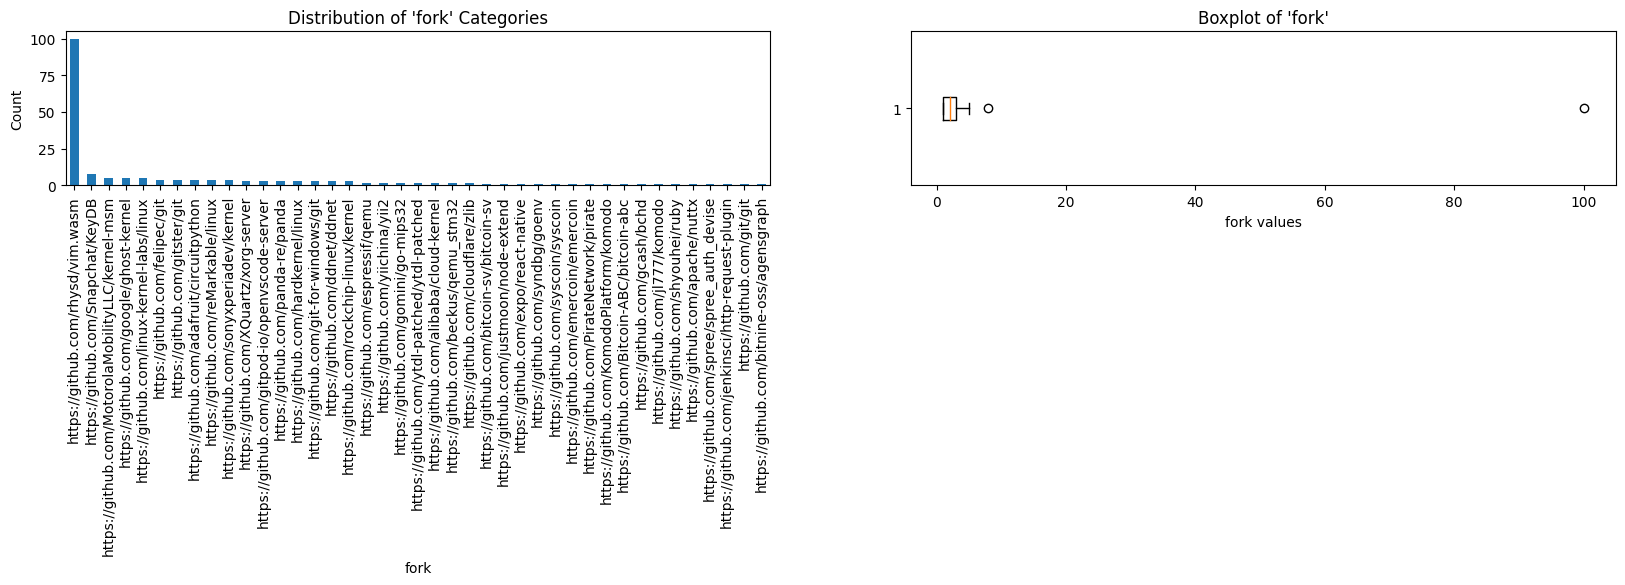

Column: fork
Total rows with data: 195
Non-empty rows: 195
Mean : 4.76
Median : 2.00
Min : 1
Max : 100
Generated 131 LaTeX macros
Prefix: fork
--------------------------------------------------
LaTeX macros exported to FINAL_SWH_OSV/data/RQ_SECTION_4_VETTING_ANALYSIS/macro/latex_macros_fork_distrib.tex


https://github.com/rhysd/vim.wasm    100
https://github.com/Snapchat/KeyDB      8
Name: fork, dtype: int64

In [6]:
output_path_macro=os.path.join(manual_analysis_dir,"macro")
output_file=os.path.join(output_path_macro,"latex_macros_fork_distrib.tex")

fig, axes = plt.subplots(1, 2, figsize=(20, 2))  # 1 ligne, 2 colonnes
counts = df['fork'].value_counts()
# --- Premier subplot : bar plot ---
counts.plot(kind='bar', ax=axes[0])
axes[0].set_title("Distribution of 'fork' Categories")
axes[0].set_xlabel("fork")
axes[0].set_ylabel("Count")

# --- Deuxième subplot : box plot ---

axes[1].boxplot(counts, vert=False)
axes[1].set_title("Boxplot of 'fork'")
axes[1].set_xlabel("fork values")

plt.tight_layout()
plt.show()

Q1 = counts.quantile(0.25)
Q3 = counts.quantile(0.75)
IQR = Q3 - Q1

# Définir les bornes
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filtrer les outliers
outliers = counts[(counts < lower_bound) | (counts > upper_bound)]



export_histogram_latex_macros(
    df, 
    "fork", 
    ",", 
    output_file=output_file ,
    prefix = None
)

outliers

In [7]:
def compute_precision_by_fork(df: pd.DataFrame) -> pd.DataFrame:
    counts = df.groupby(['fork', 'manual evaluation']).size().unstack(fill_value=0)
    # Ajouter la colonne "total"
    counts['TOTAL'] = counts['POSITIVE'] + counts['NEGATIVE']
    # Calculer le precision
    counts['PRECISION'] = counts['POSITIVE'] / counts['TOTAL']
    return counts

def compute_response_stat(df: pd.DataFrame) -> pd.DataFrame:
     owner_evaluation = df['Owner notification'].value_counts().to_frame(name='count')
     owner_evaluation.loc['TOTAL_RESPONSE'] = owner_evaluation.loc['AFFECTED', 'count'] +   owner_evaluation.loc['NOT AFFECTED', 'count']
     # Calcul du precision
     owner_evaluation.loc['response precision'] =         owner_evaluation.loc['AFFECTED', 'count'] / owner_evaluation.loc['TOTAL_RESPONSE', 'count']    
     owner_evaluation.loc['response_precision_percent']=round(owner_evaluation.loc['response precision'] *100)

     return owner_evaluation

def compute_stats(df: pd.DataFrame, response_correction =False) -> pd.DataFrame:
    manual_evaluation_analysis = df['manual evaluation'].value_counts().to_frame(name='count')
    manual_evaluation_analysis.loc['TOTAL'] = manual_evaluation_analysis.loc['POSITIVE', 'count'] +   manual_evaluation_analysis.loc['NEGATIVE', 'count']

    # Calcul du precision
    manual_evaluation_analysis.loc['precision'] = (
        manual_evaluation_analysis.loc['POSITIVE', 'count'] /
        (manual_evaluation_analysis.loc['POSITIVE', 'count'] +
        manual_evaluation_analysis.loc['NEGATIVE', 'count'])

    )
    manual_evaluation_analysis.loc['precision_percent']=round(manual_evaluation_analysis.loc['precision'] *100)
    
    if response_correction:
        response_stats = compute_response_stat(df)
        response_precision = response_stats.loc['response precision', 'count']
        manual_evaluation_analysis.loc['corrected precision']= manual_evaluation_analysis.loc['precision'] * response_precision

    precision_by_fork=compute_precision_by_fork(df)
    mean_precision = precision_by_fork['PRECISION'].mean()
    

    manual_evaluation_analysis.loc['mean of precision by fork'] = mean_precision
    return manual_evaluation_analysis

stats = compute_stats(df,True)
author_eval_path=os.path.join(output_path_macro,'latex_author_eval_macro.tex')

export_df_as_macros(stats, tex_filename=author_eval_path, prefix="AuthorEval")

stats


latex file exported : FINAL_SWH_OSV/data/RQ_SECTION_4_VETTING_ANALYSIS/macro/latex_author_eval_macro.tex (7 macros)


,count
POSITIVE,135.000000
NEGATIVE,60.000000
TOTAL,195.000000
precision,0.692308
precision_percent,69.000000
corrected precision,0.479290
mean of precision by fork,0.591382


In [8]:
# What if we exclude outliers?
author_eval_path=os.path.join(output_path_macro,'latex_author_eval_without_outlier_macro.tex')

df_excl_outliers = df[~df['fork'].isin(outliers.index)]
stats_without_outlier = compute_stats(df_excl_outliers)
export_df_as_macros(stats_without_outlier, tex_filename=author_eval_path, prefix="AuthorEvalWithoutOutlier")

stats_without_outlier

latex file exported : FINAL_SWH_OSV/data/RQ_SECTION_4_VETTING_ANALYSIS/macro/latex_author_eval_without_outlier_macro.tex (6 macros)


,count
POSITIVE,52.000000
NEGATIVE,35.000000
TOTAL,87.000000
precision,0.597701
precision_percent,60.000000
mean of precision by fork,0.600427


In [9]:
#Compute the number of distinct forks, vulne for which we have at least one positive manual evaluation
distinct_forks_with_vuln = df[df['manual evaluation'] == 'POSITIVE']['fork'].nunique()
distinct_forks_with_vuln

26

In [10]:
distinct_vulns_with_vuln = df[df['manual evaluation'] == 'POSITIVE']['vuln_id'].nunique()
distinct_vulns_with_vuln

110

In [11]:
#Compute the number of distinct forks, vulne for which we have at least one positive manual evaluation
distinct_forks_with_vuln = df[df['Owner notification'] == 'AFFECTED']['fork'].nunique()
distinct_forks_with_vuln

6

In [12]:
distinct_vulns_with_vuln = df[df['Owner notification'] == 'AFFECTED']['vuln_id'].nunique()
distinct_vulns_with_vuln

8

##

## Compute Response Precision

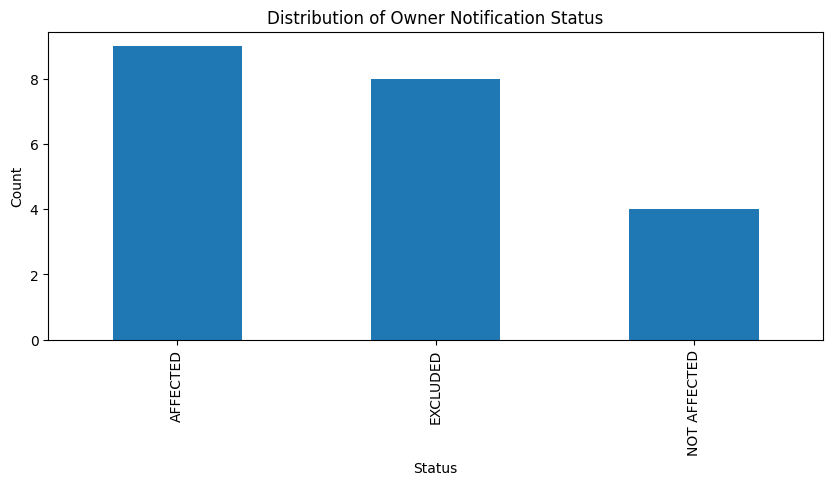

latex file exported : FINAL_SWH_OSV/data/RQ_SECTION_4_VETTING_ANALYSIS/macro/latex_response_macro.tex (6 macros)


,count
AFFECTED,9.000000
EXCLUDED,8.000000
NOT AFFECTED,4.000000
TOTAL_RESPONSE,13.000000
response precision,0.692308
response_precision_percent,69.000000


In [13]:
notif_path=os.path.join(output_path_macro,'latex_response_macro.tex')
counts = df['Owner notification'].value_counts()

plt.figure(figsize=(10, 4))
counts.plot(kind='bar')
plt.title("Distribution of Owner Notification Status")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

df_notif = df[df['Owner notification'].isin(['AFFECTED', 'NOT AFFECTED'])]
df_notif
# export_histogram_latex_macros(
#     df, 
#     "Owner notification", 
#     ",", 
#     output_file=notif_path ,
#     prefix = None
# )

response = compute_response_stat(df)
export_df_as_macros(response, tex_filename=notif_path, prefix="OwnerNotification")
response